# ML818 - Tabular Q-learning Assignment


## 1. Background

The purpose of this assignment is to implement some of the fundamental reinforcement learning algorithms using a simple gridworld environment. You will be implementing tabular Q-learning, and the SARSA algorithm and compare it to tabular Q-learning.

In order to implement a Q-learning algorithm, there are a couple of preliminaries to understand, including:
1. the gridworld environment, 
2. the action space of the agent, 
3. the observation that is returned by the environment
4. the reward signal


## 1.1 Gridworld Environment

The gridworld environment we will be using was written by Maxime Chevalier-Boisvert and can be obtained from Github

https://github.com/Farama-Foundation/gym-minigrid

or it can be installed via pip (`pip install minigrid`) 


![Title](figures/empty-env.png)

This environment is an empty room, and the goal of the agent is to reach the green goal square, which provides a sparse reward. A small penalty is subtracted for the number of steps to reach the goal. This environment is useful, with small rooms, to validate that your RL algorithm works correctly, and with large rooms to experiment with sparse rewards and exploration. The random variants of the environment have the agent starting at a random position for each episode, while the regular variants have the agent always starting in the corner opposite to the goal.

### Structure of the world:

- The world is an NxM grid of tiles
- Each tile in the grid world contains zero or one object
- Cells that do not contain an object have the value None
- Each object has an associated discrete color (string)
- Each object has an associated type:
    - 'unseen'        : 0
    - 'empty'         : 1
    - 'wall'          : 2
    - 'floor'         : 3
    - 'door'          : 4
    - 'key'           : 5
    - 'ball'          : 6
    - 'box'           : 7
    - 'goal'          : 8
- The agent can pick up and carry exactly one object (eg: ball or key)
- To open a locked door, the agent has to be carrying a key matching the door's color

The minigrid environment is compatible with OpenAI's gym environments. Any RL algorithm that is written to work with an OpenAI gym environment should also work with the minigrid environment.

The minigrid environment can be imported using the following commands:

In [1]:
# import the minigridworld environment
import gymnasium as gym
import minigrid

# Make the gym environment
#env = gym.make('MiniGrid-Empty-8x8-v0')

# Render mode = 'human' allows us to see the rendered virtual environment
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='human')

## 1.2 Actions in the basic environment:

The environment defines the following basic actions that the agent can perform each step:``

- Turn left
- Turn right
- Move forward
- Pick up an object
- Drop the object being carried
- Toggle (open doors, interact with objects)

We will only be using the first three actions, i.e. "Turn left", "Turn right" and "Move forward".

### Agent that takes random actions

To explore the environment the agent needs to be able to randomly select an action to take. This can be done by generating a random integer from 0 and one less than the number of actions in the actions space.

To generate random actions we need to import the 'random' module. Note the code below will generate any of the **six (6)** basic actions that the agent can take.


In [2]:
# import the 'random' module to generate random numbers
import random
a = random.randint(0, env.action_space.n - 1)

print("Action a: %d was generated" % a)

Action a: 6 was generated


It is important to reset the environment after each episode has ended. This sets the number of steps the agent has taken to zero, and puts the agent back on its starting position. Resetting the environment is also used to obtain the first observation representing the current state $S$.

## 1.3 Observation returned by Environment

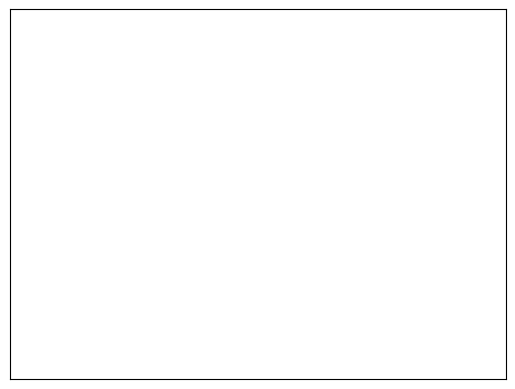

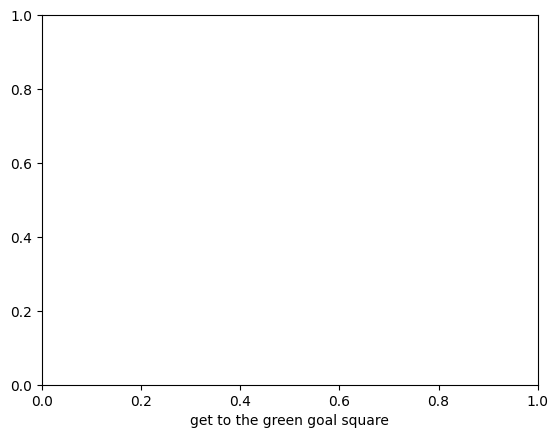

{'image': array([[[2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0]],

       [[2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0]],

       [[2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0],
        [2, 5, 0]],

       [[2, 5, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[2, 5, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[2, 5, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[2, 5, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]]], dtype=uint8), 'direction': 0, 'mission': 'get

In [3]:
# reset the environment
obs, info = env.reset()
print(obs)
print(info)


The default observation that is provided by the environment contains information that is superfluous (such as the 'direction' and the 'mission' - we are only interested in the 'image' data, though the direction data could also be useful). We use a wrapper that is provided by the minigrid environment to only extract the observation representing the partial view that the agents has of the environment.

In [15]:
from minigrid.wrappers import *
env = ImgObsWrapper(env)
env.reset()

(array([[[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0],
         [1, 0, 0]]], 

Lastly the 'image' observation contains information about each tile around the agent. Each tile is encoded as a 3 dimensional tuple: (OBJECT_IDX, COLOR_IDX, STATE), where OBJECT_TO_IDX and COLOR_TO_IDX mapping can be found in 'minigrid/minigrid.py' and the STATE can be as follows: 

    door STATE -> 0: open, 1: closed, 2: locked

For this task we are only going to be using the information contained in the OBJECT_IDX, therefore we write a small function to extract the OBJECT_IDX information.

In [16]:
# extract the object_idx information as a matrix
def extractObjectInformation(observation):
    (rows, cols, x) = observation.shape
    view = np.zeros((rows, cols))
    for r in range(rows): 
        for c in range(cols): 
            view[r,c] = obs[r,c,0]
    return view

# the following is a more efficient method of extracting the information using numpy slicing and reshaping
def extractObjectInformation2(observation):
    (rows, cols, x) = obs.shape
    tmp = np.reshape(obs,[rows*cols*x,1], 'F')[0:rows*cols]
    return np.reshape(tmp, [rows,cols],'C')

# Combine all the preprocessing fuctions into a single function
def preprocess(observation):
    return extractObjectInformation2(observation)

obs, _ = env.reset()
print(preprocess(obs))


[[2 2 2 2 2 2 2]
 [2 2 2 1 1 1 1]
 [2 2 2 1 1 1 1]
 [2 2 2 1 1 1 1]
 [2 2 2 1 1 1 1]
 [2 2 2 1 1 1 1]
 [2 2 2 1 1 1 1]]


The partial observation provided by the environment is a 7x7 grid. The observation start from the cell furthest from the direction the agent is looking on the left. Indexing is from leftmost row to right most row (row is defined as parallel to direction agent is looking). Within a row, the indexing is from furthers cell to nearest cell. In the example below the whole observation is a 7x7 matrix 'obs'. The 'x' is at index [0][0]. The agent is represented by '>' and is at index obs[3][6]. The '+' is at index obs[6][6]. The agent will always be index [3][6]. The location right in front of the agent will always be at index [3][5]. 

**Note that the observation used in this assignment does not contain '>', '+' or 'x' - it is only used for illustration.**

## 1.4 Reward Signal

The empty environment we will be using provide sparse reward. Thus the agent only receives a non-zero reward when the goal is successfully achieved. The reward upon success is determined as follows:

$r = 1 - 0.9\times \frac{\textrm{number of steps}}{\textrm{maximum number of steps}}$

The maximum number of steps of the empty environment is $4\times N\times M$ where $N\times M$ is the size of the grid. Eg. for a $8\times 8$ empty grid the maximum number of steps is 256 steps.

### Variables return from step() function

The environment returns five variables from the step() function:

[observation, reward, done, truncated, info] = env.step(...) 

- **observation** - the observation returned by the environment (as detailed above)
- **reward** - the scalar reward associated with taking the action and reaching the next state
- **done** - a boolean variable indicating if the agent reached a terminal state
- **truncated** - a boolean variable indicating if the agent did not manage to reach a terminal state, but the episode ended because the maximum number of steps was reached
- **info** - contains auxiliary diagnostic information


### Episode done
There are two instances when the episode is done:
1. When the agent succesfully reached the goal (receiving a non-zero reward), or
2. When the agent has reached the maximum number of steps of an episode (receiving a reward of zero)

# 2. Training an RL agent

Since our environment an episode is always of finite length (the agent either reaches its goal or reaches the maximum number of steps) we can train a reinforcement leaning (RL) agent agent over a number of episodes. 

The following is the main Reinforcement Learning loop for a single episode that all RL algorithms contain in some form:

## 2.1 The main RL loop (maximum of 256 steps)

In [7]:
import time

numActions = 3 # we only need the first three actions

env.reset()

for i in range(0, env.max_steps):

    # Choose an action
    # Pick a random action
    a = random.randint(0, numActions)

    # take action 'a', receive reward 'reward', and observe next state 'obs'
    # 'done' boolean variable that indicates if the termination state was reached
    # 'truncated' boolean variable that indicates if the episode was ended before reaching the termination state
    # 'info' information provided by the gym environment
    
    obs, reward, done, truncated, info = env.step(a)


    if (done == True):
        # if agent reached its goal successfully
        print('Finished episode successfully taking %d steps and receiving reward %f' % (i, reward))
        break
    if (truncated == True):
        print('Truncated episode taking %d steps and receiving reward %f' % (i, reward))
        break

        

Finished episode successfully taking 96 steps and receiving reward 0.658984


When training over multiple episodes the main RL loop illustrated above will need to be repeated inside an outer loop that iterates over the episodes:

In [8]:
# Make the gym environment
env = gym.make('MiniGrid-Empty-8x8-v0')

# declare the variable to store the tabular value-function
Q = {}

episodes = 2
max_steps = env.max_steps

# Use a wrapper so the observation only contains the grid information
env = ImgObsWrapper(env)

# reset the environment
obs, _ = env.reset()

# extract the current state from the observation
currentS = extractObjectInformation(obs)

# initialise the initial values of the value-function to be zero - this is a pessimistic initialisation
## note that using the numpy array of the observation will not work in practice, 
## you will need to calculate a hash-value of the current state and use it as unique key into the 
## dictionary 
currentS_Hash = 5
Q[currentS_Hash] = np.zeros(numActions)  

print('Start training...')
for e in range(episodes):
    for i in range(0, max_steps):

        # Choose an action
        # Pick a random action
        a = random.randint(0, numActions)

        # take action 'a', receive reward 'reward', and observe next state 'obs'
        # 'done' indicate if the termination state was reached
        obs, reward, done, truncated, info = env.step(a)
        # extract the next state from the observation
        nextS = extractObjectInformation2(obs)
        
        #env.render() # render the environment, this does not work inside Jupyter notebook

        # sleep for 50 milliseconds so we can see the rendering of the environment. 
        #time.sleep(0.05) # When training without rendering remove this line
        if (done == True):
            # if agent reached its goal successfully
            print('Finished episode successfully taking %d steps and receiving reward %f' % (i, reward))
            break
        if (truncated == True):
            # agent failed to reach its goal successfully 
            print('Truncated episode taking %d steps and receiving reward %f' % (i, reward))
            break
            
        # since the episode is not done, store the next state as the current state for the next step
        currentS = nextS
        
print('Done training...')

Start training...
Truncated episode taking 255 steps and receiving reward 0.000000
Truncated episode taking 0 steps and receiving reward 0.000000
Done training...


## 2.2 Loading and saving the value-function

It is useful to be able to load and save the value-function Q. Assuming that we use a Python dictionary to store the value-function, the table can be saved and reloaded using Python's pickle module as illustrated below:

In [24]:
import pickle
from os.path import exists

# declare value-function Q as Python dictionary
Q = {}

filename = 'qtable.pickle'

# Saving the value-function to file
with open(filename, 'wb') as handle:
    pickle.dump(Q, handle, protocol=pickle.HIGHEST_PROTOCOL)
    handle.close()

# Loading the value-function from file
if (exists(filename)):
    print('Loading existing Q values')
    # Load data (deserialize)
    with open(filename, 'rb') as handle:
        Q = pickle.load(handle)
        handle.close()
else:
    print('Filename %s does not exist, could not load data' % filename)        
        

Loading existing Q values


## 2.3 Epsilon-Greedy Exploration

When the agent initially starts training, it does not know anything about the environment, or which actions will result in a positive reward. The agent therefore initially needs to take random actions in order to _explore_ and learn about the environment. When the agent has learnt more about the environment (by estimating the value-function), the agent can start to _exploit_ the environment, by taking an action that maximimes its expected total reward. One algorithm that is used to control the amount of exploration vs. exploitation is called _Epsilon-Greedy Exploration_.

The main idea is that initially a $\epsilon$-value is set to a value $\epsilon_{\textrm{max}}$ where $\epsilon_{\textrm{max}} < 1$. The $\epsilon$-value is gradually decreased to a minimum value $\epsilon_{\textrm{min}}$ where $\epsilon_{\textrm{min}}>0$.

At each step, when the agent needs to select an action, it generates a random value between 0 and 1. If the value is smaller than the current $\epsilon$-value, the agent _explores_ the environment by taking a random action. If the value is bigger than the current $\epsilon$-value, the agent _exploits_ what is has learnt by taking an action that will maximise its expected reward. This is done by taking the action, which will result in the highest value-function, given the current state of the environment (the state is extracted from the current observation).

This can be implemented as follows:

In [9]:
epsilon = 0.99

# perform epsilon greedy action
if (random.random() < epsilon):
    # Explore the environment by selecting a random action
    a = random.randint(0, numActions)
else:
    # Exploit the environment by selecting an action that is the maximum of the value function at the current State
    a = np.argmax(Q[currentS_Key])
print(a)

3


The maximum and minimum $\epsilon$-values ($\epsilon_{\textrm{max}}$ and $\epsilon_{\textrm{min}}$) are the first of the hyperparameters that will need to be tuned to obtain good performance when training the RL-agent. Typical values are  $\epsilon_{\textrm{max}} = 0.99$ and $\epsilon_{\textrm{min}} = 0.05$. This means that initially the agent will explore and take random actions 99\% of the time, while at the end of training it will only explore the environment 5\% of the time (exploiting 95\% of the time). The $\epsilon$-value can be decayed by multiplying it with a decay-value smaller than 1 (typically a decay-value of 0.999 can be used).

## 2.4 Q-learning

Q-learning updates its estimate of the value-function (the Q-table) at each time-step. The update equation is as follows:

$$ Q(S,A)= Q(S,A)+\alpha\left[R+\gamma\max_{a}Q(S′,a)− Q(S,A) \right]$$ where the $S$ is the current state, $A$ is the action that was taken, $S'$ is the next state after taking action $A$, $\alpha$ is the learning rate and $\gamma$ is the discount factor.

This update equation can also be written as follows:

$$ Q(S,A)= (1-\alpha)Q(S,A)+\alpha\left[R+\gamma\max_{a}Q(S′,a)\right]$$

The learning rate $\alpha$ determines how much we change our current Q value towards the discounted maximum of its successors. If we would chose $\alpha=0$, we wouldn’t change anything, if we chose $\alpha=1$ we completely replace the old Q-value with the new value, if we chose $\alpha=0.5$, we would get the average between the old value and the new value. 

The discount factor $\gamma$  essentially determines how much the agent cares about rewards in the distant future relative to those in the immediate future. If $\gamma=0$, the agent will only learn about actions that produce an immediate reward. If $\gamma=1$, the agent will evaluate each of its actions based on the sum total of all of its future rewards. Therefore a discount factor of $0\leq\gamma\leq 1$ must be used with a typical value being $\gamma = 0.9$. 

The learning rate $\alpha$ and the discount factor $\gamma$ are also hyperparameters that must be tuned during training.

## 2.5 SARSA

SARSA also updates its estimate of the value-function (the Q-table) at each time-step. The update equation is as follows:

$$ Q(S,A)= Q(S,A)+\alpha\left[R+\gamma Q(S′,A')− Q(S,A) \right]$$ where the $S$ is the current state, $A$ is selected in an $\epsilon$-greedy fashion with respect to $Q(S,a)$, $S'$ is the next state after taking action $A$ and receiving reward $R$, and $A'$ is action that is selected in an $\epsilon$-greedy fashion with respect to $Q(S', a)$. $A'$ is also the action that will be performed in the next step. Lastly, $\alpha$ is the learning rate and $\gamma$ is the discount factor.

This update equation can also be written as follows:

$$ Q(S,A)= (1-\alpha)Q(S,A)+\alpha\left[R+\gamma Q(S′,A')\right]$$

The learning rate $\alpha$ and the discount factor $\gamma$ are also hyperparameters that must be tuned during training.

## 2.6 Value-function Table (Q-Table)

For tabular Q-learning the value-function will be stored in a table. The table should have an entry for each state-action pair $(S,A)$. For our environment there are 6 basic actions (although we only use 3). If we use a Python dictionary to store the Q-table, we can use the state $S$ as a key to the dictionary, and then store a Numpy array which has a length of 6 (when using all 6 basic actions) or 3 (when only using 3 actions) to store the value-functions for each action at that state $S$. 

In this assignment the state $S$ is represented as a 7x7 matrix representing the objects seen by the agent (see Section 1.3). Python does not allow us to use a matrix as the key of a dictionary, thus we need to calculate a hash function of the matrix, which can then be used as key for the dictionary representing the Q-table. Each unique state $S$ will thus have a corresponding hash value $S_{\textrm{key}}$ which is used as key to store and retrieve the value-functions associated with the agent taking each action from that state $S$. 

**You will need to select an appropriate hash function to generate a unique key for each state.** An example Python function that is the start of such a hash function is given below:

In [10]:
import hashlib

def hashState(state):
    hash = random.randint(0,1e10) # Don't use a random number generator as a hash function!!!!
    # calculate hash value of state
    return hash

currentState = np.array([[2, 2, 2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2, 2, 2],
       [2, 1, 1, 1, 1, 1, 1],
       [2, 1, 1, 1, 1, 1, 1],
       [2, 1, 1, 1, 1, 1, 1],
       [2, 1, 1, 1, 1, 1, 1]])

hashState(currentState)

2553803047

## 2.7 Hyperparameter tuning

Hyperparameters are parameters whose values control the learning process and determine the values of model parameters that a learning algorithm ends up learning. 

A simple method of performing hyperparameter tuning is to perform a grid search (or parameter sweep) over the possible range of hyperparameter values. A full training and evalation run is performed over all the possible combinations of hyperparameters. The disadvantage of a grid search is that it is an exhaustive search and therefore suffers from the curse of dimensionality.

Other approaches to hyperparameter tuning can be found on [Wikipedia](https://en.wikipedia.org/wiki/Hyperparameter_optimization).

## 2.8 Plotting the results

We can use Tensorboard to plot the average reward as a function of the training steps taken. We first need to import the Pytorch tensorboard module:

In [11]:
from torch.utils.tensorboard import SummaryWriter

We create a Tensorboard writer to which we will write the reward and number of training steps taken as we finish each episode. The default is that Tensorboard will write the training records to file in the new directory called "runs". 

In [12]:
# Tensorboard writer
writer = SummaryWriter()

During training we want to store both the loss function as a function of the number of training steps and the reward at the end of each episode. Create a counter 'steps_done' to record the total number of training steps that have been taken. The counter is incremented each time we select an action.

In [13]:
# Before training
steps_done = 0

# Each time an action is selected, increment the 'steps_done' counter 
steps_done += 1

At the end of each episode we will add both the reward as well as the total number of training steps at that point to the writer.

In [14]:
if done:
    writer.add_scalar("Reward/train", reward, steps_done)

After the agent have completely finished training, we need to flush any data that has not yet been written to file, and also close the writer.

In [15]:
writer.flush()
writer.close()

At any point during the training we can view the training results using a browser. We first need to start a local TensorBoard server using the following command:

> tensorboard --logdir=runs

We can then view the training results by pointing our browser to the url: http://localhost:6006 which should look like the following:

![Tensorboard example](figures/Tensorboard_example.png)


# 3. Assignment

## 3.1 Warmup Task

Write a Python script that has an agent that generates random actions every step

## 3.2 Task 1 - Tabular Q-learning

Implement an agent that does tabular Q-learning. The partial observation (representing the objects in the tiles around the agent) is the state of the agent. The agent must also implement $\epsilon$-greedy exploration where the $\epsilon$-value must decay as training progresses. The hyper-parameters is the learning rate $\alpha$, the discount factor $\gamma$ the maximum and miminum $\epsilon$-greedy value $\epsilon_{\textrm{max}}$ and $\epsilon_{\textrm{min}}$.

1. Train a policy for the agent for a maximum of 3000 episodes using Q-learning. Plot the reward as a function of the training steps.
2. Evaluate the performance of the trained policy by calculating the episode completion rate (the percentage of episode that the agent reached the goal), the average number of steps and the average reward over 1000 evaluation episodes.
3. Perform hyper-parameter tuning to find optimal training values that will result in the highest average reward and completion rate.

Hint: Use a dictionary to store the value function Q. Use a hash function to generate a unique key for each state of the agent.

The instructor's best performance current policy achieved a completion rate of 100%, with 12 average steps and average reward of 0.9578. Your mark for the assignment will be the average reward of your best performing agent as compared to the instructor's best performing policy. If your agent does better than the instructor's agent, you will still receive only a maximum of 100% for that part of the assignment.


## 3.3 Task 2 - SARSA
Implement the SARSA algorithm and compare the policy trained with SARSA to the tabular Q-learning agent trained in Task 1. 

# Submission, Report and Grading

## Submission of Week 1 Assignment

The following items must be submitted as a single zip file on SUNLearn.

1. All your code. The code should be well documented.
2. Your best performing agent for Task 1 - i.e. the Q-table that you trained and saved using the pickle module (as well as the code to load your agent).
3. Your best performing agent for Task 2 - i.e. the best performing SARSA agent that you saved using the pickle module (as well as the code to load your agent).
5. A readme explaining how to run your code - typically 'python task.py'
6. A PDF of your report


## Report for first week's assignment

Write a report detailing Task 1 (implementation and training of the tabular Q-learning method). Your report should at minimum cover the following aspects for Task 1:

- Implementation of the table to store the value function
- Figures plotting the average reward as a function of the number of training steps.
- A discussion on how you tuned the hyperparameters to achieve good performance
- The evaluation of the trained agent by calculating the average goal completion rate and the average reward over 1000 episodes.

For Task 2 (implementation and training of the tabular SARSA method), your report should cover the following aspects:
- Background theory of SARSA.
- Figures plotting the average reward as a function of the number of training steps.
- The evaluation of the trained agent by calculating the average goal completion rate and the average reward over 1000 episodes.
- A comparison of the training curves and performance of SARSA and your implementation of the tabular Q-learning method.

### Important concepts for the report 

- The content related to the first week's assignment should be less than 6 pages.
- The report should follow a two-column format. I recommend using either the [IEEE template](https://www.overleaf.com/latex/templates/ieee-bare-demo-template-for-conferences/ypypvwjmvtdf) or the [ICML template](https://www.overleaf.com/latex/templates/icml2021-template/dsftnbmjgyhv).
- It should have a proper title, i.e. not “Assignment 1”.
- It should have an abstract, describing the motivation, problem statement, approach,
results, and conclusions. See [Philip Koopman’s guide](http://users.ece.cmu.edu/~koopman/essays/abstract.html).
- It should have an introduction, answering two questions: (1) what is the problem
you addressed? and (2) what is your contributions in the way you addressed it? See
[Sharon Goldwater’s guide](https://homepages.inf.ed.ac.uk/sgwater/writing/content.html).
- It should have a conclusion, telling the reader what they should take away from your
report.
- Figure captions should be full sentences.
- You need to have references, showing where you found the information for the different
models and evaluation approaches. The references in your bibliography need to be
consistent.
- In fact, everything needs to be consistent. See [Prof Herman Kamper's guide](https://www.kamperh.com/notes/writing).
- The report should be beautiful.

## Grading

The mark for the practical assignment is split into three components:
1. Report - Your final report contributes **30.0%** of the final mark
2. Week 1 Assignment - Q-Learning
    1. **Task 1**: The performance of your tabular Q-learning agent (as compared to the instructor's best-performing agent) contributes **50%** of the final mark.
    2. **Task 2**: The performance of your chosen value-based method (as compared to the instructor's best-performing tabular Q-learning agent) contributes **20%** bonus marks to the final mark.
3. Week 2 Assignment - Deep Q Networks
    1. **Task 3**: The performance of your DQN-learning agent (as compared to the instructor's best-performing agent) will NOT contribute towards your final mark.
    2. **Task 4**: The performance of your RBG-image DQN-learning agent (as compared to the instructor's best-performing agent) will NOT contribute towards your final mark.

## 4. Instructor

Prof Herman Engelbrecht is the instructor for this practical assignment. He can be contacted via email [hebrecht@sun.ac.za](mailto:hebrecht@sun.ac.za)